In [1]:
%matplotlib widget

### Inci's Preliminary Dispersion Calculation Code

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from g4beam import *
from scan import *
from scipy.optimize import differential_evolution
from matplotlib.cm import viridis
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import re
import sys
from pathlib import Path
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
import os
from tabulate import tabulate
import tempfile
import glob
import json
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
# If particles_after isn't updated with Z = 0.
def convertZ(input_file, output_file):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = "0"  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None
convertZ("particles_afterupt.txt", "particles_after.txt")

In [ ]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

In [ ]:
# Load data POST WEDGE as a Dataframe so that you can use Daniel Fu's functions
filename = "out_1760039204_1614938.txt"

# Skip the first two header lines that start with '#'
with open(filename) as f:
    # Read until the line containing column names
    for line in f:
        if line.startswith("#x "):
            columns = line.strip().lstrip("#").split()
            break

# Now load the data into a DataFrame
df = pd.read_csv(filename, comment="#", sep='\s+', names=columns)

x_params, y_params, z_emit = calc_all_params(df) # _params are tuples of the form (emittance, beta, gamma, alpha, D, D')
D_dict = {"D_x": x_params[4], "D'_x": x_params[5], "D_y": y_params[4], "D'_y": y_params[5]}
print(D_dict)
cost = D_dict["D_x"]**2 + D_dict["D'_x"]**2 + D_dict["D_y"]**2 + D_dict["D'_y"]**2 
print(cost)
print(r"Epsilon_z: "+str(z_emit))

In [ ]:
# Replace with your beam file
filename = "out_1760039204_1614938.txt"

# Load data assuming BLTrackFile columns: x y z px py pz t particleID ...
# Adjust columns if your file is different
data = np.loadtxt(filename, comments="#")

# Extract px, py, pz
px = data[:, 3]
py = data[:, 4]
pz = data[:, 5]

# Compute average momentum components
px_ref = np.mean(px)
py_ref = np.mean(py)
pz_ref = np.mean(pz)

# Compute average total momentum magnitude
p_ref = np.sqrt(px_ref**2 + py_ref**2 + pz_ref**2)

print(f"Reference particle momentum components: px={px_ref:.6f}, py={py_ref:.6f}, pz={pz_ref:.6f}")
print(f"Reference particle total momentum: p = {p_ref:.6f}")

In [ ]:
desired_p = np.array([-0.204087, -0.204087, 88.961842])  # px, py, pz in MeV/c

data = np.loadtxt("out_1760039204_1614938.txt")
momenta = data[:, 3:6]  # px, py, pz

# Find the particle index closest to desired momentum
dist = np.linalg.norm(momenta - desired_p, axis=1)
ref_index = np.argmin(dist)

print("Use this index in referenceParticle:", ref_index)


In [ ]:
import re
def parse_best_result(text):
    # Regex: captures variable name and numeric value (supports +/-, decimals, exponents)
    pattern = r"([A-Za-z0-9_]+)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    matches = re.findall(pattern, text)

    # Convert to dictionary
    result_dict = {k: float(v) for k, v in matches}

    # Optional: turn into NumPy array (just the values)
    keys = list(result_dict.keys())
    values = np.array([result_dict[k] for k in keys])

    # Print them as a Python-style array
    print(", ".join(str(v) for v in values[:-1]))

    return result_dict, keys, values
text = input("Paste the best result from optimization")
result_dict, keys, xvec = parse_best_result(text)

In [35]:
# ---------------- USER CONFIG ----------------
G4BEAMLINE_CMD = "g4bl"
TEMPLATE_FILE = "G4_FinalCooling_wdc_Template_wBx.g4bl"
OUTPUT_DIR = "runs"
VD_FILENAME = "vd_B1_end_achromat.txt"   # virtual detector writes this file (ascii)
N_PARTICLES = 5000             # increase for lower noise
G4BLFILE = f"G4_FinalCooling_wdc_Template_wBx_run.g4bl"
G4BLOUTPUT =f"/home/incik/Cooling_4D/AchromatOneByOne/{VD_FILENAME}"
E0 = 1e4                       # beam energy (GeV) - for a muon collider

# Let's first take in the parameters that the wedge has
import re
import math
import sys
from pathlib import Path

def read_g4bl_params(filename):
    """
    Reads 'param' definitions from a .g4bl file and returns a dict of parameter names and values.
    """
    params = {}
    pattern = re.compile(r"param\s+(?:-unset\s+)?(\w+)=([^\s#]+)")
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("param"):
                continue
            m = pattern.search(line)
            if m:
                key, val = m.groups()
                try:
                    params[key] = float(eval(val, {"__builtins__": None, "pi": math.pi}))
                except Exception:
                    params[key] = val  # keep as string if not numeric
    return params


def compute_wedge_geometry(params):
    """
    Given parameters like absLEN3, abshgt, abswidth, abshalfangle3, compute geometry info.
    """
    W = params.get("absLEN3")
    H = params.get("abshgt")
    L = params.get("abswidth")
    half_angle_deg = params.get("abshalfangle3")
    offset = params.get("absoffset3", 0)

    if L and half_angle_deg:
        half_angle_rad = math.radians(half_angle_deg)
        thickness_tip = L / (2 * math.tan(half_angle_rad))
    else:
        thickness_tip = None

    return {
        "Length_Wedge": L,
        "Height_Base": H,
        "Width_Base": W,
        "Half-angle": half_angle_deg,
        "Tip Thickness": thickness_tip,
        "Offset": offset
    }


if len(sys.argv) < 2:
    print("Usage: python read_wedge_params.py <file.g4bl>")
    sys.exit(1)

file_path = "G4_FinalCooling_wdc_Template_wBx.g4bl"
params = read_g4bl_params(file_path)
geom = compute_wedge_geometry(params)

print("Parameters found:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

print("Derived geometry:")
for k, v in geom.items():
    print(f"  {k:20s}: {v}")

Parameters found:
  zbegin          = 0.0
  steppingFormat  = N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
  fieldVoxels     = 400,400,400
  maxStep         = 0.5
  minRangeCut     = 1.0
  nparticles      = 1000.0
  beamfile        = particles_before.txt
  pi              = 3.141592654
  degrad          = $pi/180
  abshgt          = 10.0
  abswidth        = 100.0
  absLEN3         = 18.0
  abshalfangle3   = 45.0
  absoffset3      = 3.2
  wedge_z         = 0.5*$absLEN3
  VDRad           = 60.0
  wedgeAxis       = 0.0
  noWedge         = 0.0
Derived geometry:
  Length_Wedge        : 100.0
  Height_Base         : 10.0
  Width_Base          : 18.0
  Half-angle          : 45.0
  Tip Thickness       : 50.00000000000001
  Offset              : 3.2


In [36]:
# {B1_field}, {B1_width}, {B1_height}, {B1_length}, {B1_z}, {Q1_gradient}, {Q1_length}, {radius_q}
# {B2_field}, {B2_width}, {B2_height}, {B2_length}
# {Drift1_width}, {Drift1_height}, {Drift1_length}, 
# {Drift2_width}, {Drift2_height}, {Drift2_length}

var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length", "B1_z",
            "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
            "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME"]
    
xvec = np.array([int(N_PARTICLES), -0.133, 74.7401, geom["Length_Wedge"], 267.6652, 177.7786, -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 
                144.8055, 53.6328, 120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456, VD_FILENAME])
calcparams = {name: val for name, val in zip(var_names, xvec)}

GAP = 0.1  # in mm (can be up to 1.0 safely)
B1_z_val = float(calcparams["B1_z"])
L_B1 = float(calcparams["B1_length"])
L_D1 = float(calcparams["Drift1_length"])
L_Q1 = float(calcparams["Q1_length"])
L_D2 = float(calcparams["Drift2_length"])
L_B2 = float(calcparams["B2_length"])

Drift1_z = B1_z_val + (L_B1/2) + (L_D1/2) + GAP
Q1_z     = Drift1_z + (L_D1/2) + (L_Q1/2) + GAP
Drift2_z = Q1_z + (L_Q1/2) + (L_D2/2)+ GAP
B2_z     = Drift2_z + (L_D2/2) + (L_B2/2) + GAP
VD_z     = B2_z + (L_B2/2) + 10.0 + GAP

B1_end = B1_z_val + (L_B1/2)
D1_end = Drift1_z + (L_D1/2)
Q1_end = Q1_z + (L_Q1/2)
D2_end = Drift2_z + (L_D2/2)
B2_end = B2_z + (L_B2/2)

add_params = {"Drift1_z": Drift1_z, "Q1_z": Q1_z, "Drift2_z":Drift2_z, "B2_z": B2_z, "VD_z": VD_z, 
            "B1_end": B1_end, "B2_end": B2_end,  "D1_end": D1_end, "Q1_end": Q1_end,  "D2_end": D2_end}

calcparams.update(add_params)

for k, v in calcparams.items():
    if k == "N_PARTICLES" or k == "VD_FILENAME":
        continue
    else:
        calcparams[k] = float(v)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [37]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, out_path, replacements):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

# How to Use?
print(calcparams)
write_input_from_template(TEMPLATE_FILE, G4BLFILE, calcparams)

{'N_PARTICLES': np.str_('5000'), 'B1_field': -2.8689794312826025, 'B1_width': 74.7401, 'B1_height': 100.0, 'B1_length': 267.6652, 'B1_z': 20.4404, 'B2_field': -2.8689794312826025, 'B2_width': 167.5582, 'B2_height': 144.8055, 'B2_length': 53.6328, 'VD_FILENAME': np.str_('vd_B2_achromat.txt'), 'B2_z': 181.1894, 'B1_end': 154.27300000000002, 'B2_end': 208.00580000000002}


In [38]:
# Run g4bl and get the Output file
if os.path.exists("field_cell.dat"):
    os.remove("field_cell.dat")
result = subprocess.run(["g4bl", G4BLFILE], capture_output=True, text=True, check=True)
print(result)

CalledProcessError: Command '['g4bl', 'G4_FinalCooling_wdc_Template_wBx_run.g4bl']' returned non-zero exit status 99.

In [23]:
# Make the results a dataframe and calculate the Courant-Snyder Parameters
df = read_trackfile(G4BLOUTPUT)
x_params, y_params, z_emit = calc_all_params(df)

In [ ]:
x_params, y_params, z_emit
D_dict = {"D_x": x_params[4], "D'_x": x_params[5], "D_y": y_params[4], "D'_y": y_params[5]}
print(D_dict)
cost = D_dict["D_x"]**2 + D_dict["D'_x"]**2 + D_dict["D_y"]**2 + D_dict["D'_y"]**2 
print(cost)
print(r"Epsilon_z: "+str(z_emit))

## Varying Some Parameters

In [51]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [52]:
# ---------------- USER CONFIG ----------------
G4BEAMLINE_CMD = "g4bl"
TEMPLATE_FILE = "G4_FinalCooling_wdc_Template.g4bl"
OUTPUT_DIR = "runs"
VD_FILENAME = "vd_B1_end_achromat"   # virtual detector writes this file (ascii)
N_PARTICLES = 5000             # increase for lower noise
G4BLFILE = f"G4_FinalCooling_wdc_run"
E0 = 1e4                       # beam energy (GeV) - for a muon collider
os.makedirs(OUTPUT_DIR, exist_ok=True)

def read_g4bl_params(filename):
    """
    Reads 'param' definitions from a .g4bl file and returns a dict of parameter names and values.
    """
    params = {}
    pattern = re.compile(r"param\s+(?:-unset\s+)?(\w+)=([^\s#]+)")
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("param"):
                continue
            m = pattern.search(line)
            if m:
                key, val = m.groups()
                try:
                    params[key] = float(eval(val, {"__builtins__": None, "pi": math.pi}))
                except Exception:
                    params[key] = val  # keep as string if not numeric
    return params


def compute_wedge_geometry(params):
    """
    Given parameters like absLEN3, abshgt, abswidth, abshalfangle3, compute geometry info.
    """
    W = params.get("absLEN3")
    H = params.get("abshgt")
    L = params.get("abswidth")
    half_angle_deg = params.get("abshalfangle3")
    offset = params.get("absoffset3", 0)

    if L and half_angle_deg:
        half_angle_rad = math.radians(half_angle_deg)
        L_centerline = W / math.sin(half_angle_rad)

    return {
        "Length_Wedge": L,
        "Height_Base": H,
        "Width_Base": W,
        "Half-angle": half_angle_deg,
        "Centerline_Coords": L_centerline,
        "Offset": offset
    }


if len(sys.argv) < 2:
    print("Usage: python read_wedge_params.py <file.g4bl>")
    sys.exit(1)

file_path = "G4_FinalCooling_wdc_Template.g4bl"
params = read_g4bl_params(file_path)
geom = compute_wedge_geometry(params)

print("Parameters found:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

print("Derived geometry:")
for k, v in geom.items():
    print(f"  {k:20s}: {v}")

Parameters found:
  zbegin          = 0.0
  steppingFormat  = N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
  fieldVoxels     = 400,400,400
  maxStep         = 0.5
  minRangeCut     = 1.0
  nparticles      = 1000.0
  beamfile        = particles_before.txt
  pi              = 3.141592654
  degrad          = $pi/180
  abshgt          = 10.0
  abswidth        = 100.0
  absLEN3         = 18.0
  abshalfangle3   = 45.0
  absoffset3      = 3.2
  wedge_z         = 0.5*$absLEN3
  VDRad           = 60.0
  wedgeAxis       = 0.0
  noWedge         = 0.0
Derived geometry:
  Length_Wedge        : 100.0
  Height_Base         : 10.0
  Width_Base          : 18.0
  Half-angle          : 45.0
  Centerline_Coords   : 25.455844122715714
  Offset              : 3.2


In [54]:
# Calculate all will-be-added parameters in the template
def add_missing_params(calcparams_given):
    GAP = 0.1  # in mm (can be up to 1.0 safely)
    A_GAP = 5 # mm
    L_B1 = float(calcparams_given["B1_length"])
    L_D1 = float(calcparams_given["Drift1_length"])
    L_Q1 = float(calcparams_given["Q1_length"])
    L_D2 = float(calcparams_given["Drift2_length"])
    L_B2 = float(calcparams_given["B2_length"])

    B1_z = geom["Centerline_Coords"] + (L_B1/2) + A_GAP
    Drift1_z = B1_z + (L_B1/2) + (L_D1/2) + GAP
    Q1_z     = Drift1_z + (L_D1/2) + (L_Q1/2) + GAP
    Drift2_z = Q1_z + (L_Q1/2) + (L_D2/2)+ GAP
    B2_z     = Drift2_z + (L_D2/2) + (L_B2/2) + GAP
    VD_z     = B2_z + (L_B2/2) + 10.0 + GAP

    B1_end = B1_z_val + (L_B1/2)
    D1_end = Drift1_z + (L_D1/2)
    Q1_end = Q1_z + (L_Q1/2)
    D2_end = Drift2_z + (L_D2/2)
    B2_end = B2_z + (L_B2/2)

    add_params = {"B1_z": B1_z, "Drift1_z": Drift1_z, "Q1_z": Q1_z, "Drift2_z":Drift2_z, "B2_z": B2_z, "VD_z": VD_z, 
            "B1_end": B1_end, "B2_end": B2_end,  "D1_end": D1_end, "Q1_end": Q1_end,  "D2_end": D2_end}

    calcparams_given.update(add_params)
    
    for k, v in calcparams_given.items():
        if k == "N_PARTICLES" or k == "VD_FILENAME":
            continue
        else:
            calcparams_given[k] = float(v)
    
    return calcparams_given

# Write values to the prepared G4BL template
def write_input_from_template(template_path, out_path, replacements):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [89]:
# Doing this for B1 and B1_length
B1_field_range = np.arange(-8.0, 8.0, 0.5)
B1_length_range = np.linspace(0, 320, 10)

# Initialize lists
results = []

for L_val in B1_length_range:
    Dx, Dy, Dxp, Dyp, Dip1, emit_x, emit_y, emit_z, transmission, x, xp, y, yp  = [], [], [], [], [], [], [], [], [], [], [], [], []

    for i, B_val in enumerate(tqdm(B1_field_range, desc=f"L = {L_val:.1f}")):
        if os.path.exists("field_cell.dat"):
            os.remove("field_cell.dat")

        var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length",
                    "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
                    "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME"]

        xvec = np.array([
            int(N_PARTICLES), B_val, 74.7401, geom["Length_Wedge"], L_val,
            -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 144.8055, 53.6328,
            120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456,
            f"./runs/{VD_FILENAME}_{L_val:.1f}_{i}.txt"
        ])

        calcparams = {name: val for name, val in zip(var_names, xvec)}

        add_missing_params(calcparams)
        write_input_from_template(
            TEMPLATE_FILE,
            f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{L_val:.1f}_{i}.g4bl",
            calcparams
        )

        subprocess.run(["g4bl", f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{L_val:.1f}_{i}.g4bl"], 
                    capture_output=True, text=True, check=True)

        G4BLOUTPUT = f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{VD_FILENAME}_{L_val:.1f}_{i}.txt"
        
        # Count surviving particles
        with open(G4BLOUTPUT) as f:
            N_out = sum(1 for line in f if not line.startswith("#") and line.strip())

        # Compute transmission (%)
        trans_percent = 100.0 * N_out / int(N_PARTICLES)
        transmission.append(trans_percent)
        
        df = read_trackfile(G4BLOUTPUT)
        
        # Compute normalized momenta and get position for plotting phase space
        xp.append(df["Px"] / df["Pz"])   # x' = Px/Pz
        yp.append(df["Py"] / df["Pz"])   # y' = Py/Pz
        x.append(df["x"])
        y.append(df["y"])
        
        x_params, y_params, z_emit = calc_all_params(df)

        Dip1.append(B_val)
        Dx.append(x_params[4])
        Dy.append(y_params[4])
        Dxp.append(x_params[5])
        Dyp.append(y_params[5])
        emit_x.append(x_params[0])
        emit_y.append(y_params[0])
        emit_z.append(z_emit)

    # store all results for this L_val
    results.append({
        "B1_length": L_val,
        "Dip1": Dip1,
        "Dx": Dx, "Dy": Dy, "Dxp": Dxp, "Dyp": Dyp, "xp": xp, "yp": yp, "x": x, "y":y,
        "emit_x": emit_x, "emit_y": emit_y, "emit_z": emit_z, "transmission": transmission
    })

L = 320.0:  91%|█████████ | 29/32 [00:50<00:04,  1.58s/it]/home/incik/Cooling_4D/AchromatOneByOne/g4beam.py:105: RuntimeWarning: invalid value encountered in sqrt
  e = np.sqrt(eb * ey - np.square(ea))  # mm
L = 320.0:  94%|█████████▍| 30/32 [00:52<00:03,  1.56s/it]/home/incik/Cooling_4D/AchromatOneByOne/g4beam.py:105: RuntimeWarning: invalid value encountered in sqrt
  e = np.sqrt(eb * ey - np.square(ea))  # mm
/home/incik/Cooling_4D/AchromatOneByOne/g4beam.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  eb / e / 1000,  # mm --> m
/home/incik/Cooling_4D/AchromatOneByOne/g4beam.py:113: RuntimeWarning: divide by zero encountered in scalar divide
  ey / e * 1000,  # 1/mm --> 1/m
/home/incik/Cooling_4D/AchromatOneByOne/g4beam.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  ea / e,  # dimensionless
L = 320.0:  97%|█████████▋| 31/32 [00:53<00:01,  1.55s/it]/home/incik/Cooling_4D/AchromatOneByOne/g4beam.py:102: RuntimeWarning: invalid value encount

In [84]:
def find_first_zero_crossing(x_vals, y_vals):
    """Return the first B where y crosses zero (linear interpolation)."""
    y_vals = np.array(y_vals)
    x_vals = np.array(x_vals)
    
    for i in range(len(y_vals)-1):
        if y_vals[i] * y_vals[i+1] <= 0:  # sign change or exact zero
            x0, x1 = x_vals[i], x_vals[i+1]
            y0, y1 = y_vals[i], y_vals[i+1]
            if y1 != y0:
                zero_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
            else:
                zero_cross = x0
            return zero_cross
    return np.nan  # no zero-crossing found

# Build clean table
table_data = []
for res in results:
    L_val = res["B1_length"]
    table_data.append({
        "B1_length": L_val,
        "B_for_Dx0": find_first_zero_crossing(res["Dip1"], res["Dx"]),
        "B_for_Dy0": find_first_zero_crossing(res["Dip1"], res["Dy"]),
        "B_for_Dxp0": find_first_zero_crossing(res["Dip1"], res["Dxp"]),
        "B_for_Dyp0": find_first_zero_crossing(res["Dip1"], res["Dyp"])
    })

df_table = pd.DataFrame(table_data)
print(df_table)

# Optional: save as CSV
df_table.to_csv("B1_length_zero_crossings.csv", index=False)


    B1_length  B_for_Dx0  B_for_Dy0  B_for_Dxp0  B_for_Dyp0
0    0.000000  -6.285777  -7.196239    6.750476   -0.409959
1   35.555556  -2.817974  -7.694747    2.819152   -7.557208
2   71.111111   0.461571  -7.931421    1.262773   -7.632041
3  106.666667   0.775301  -7.767469   -6.707320   -7.593850
4  142.222222   0.764816  -5.828198   -5.474995   -7.466218
5  177.777778  -5.937964  -7.909045   -3.909954   -7.629308
6  213.333333  -4.312222  -7.523397   -3.317570   -7.441171
7  248.888889  -3.638287  -7.444413   -2.489890   -7.188919
8  284.444444  -3.136290  -7.523583   -2.288095   -7.037807
9  320.000000  -2.685096  -6.334542   -2.146273   -6.349840


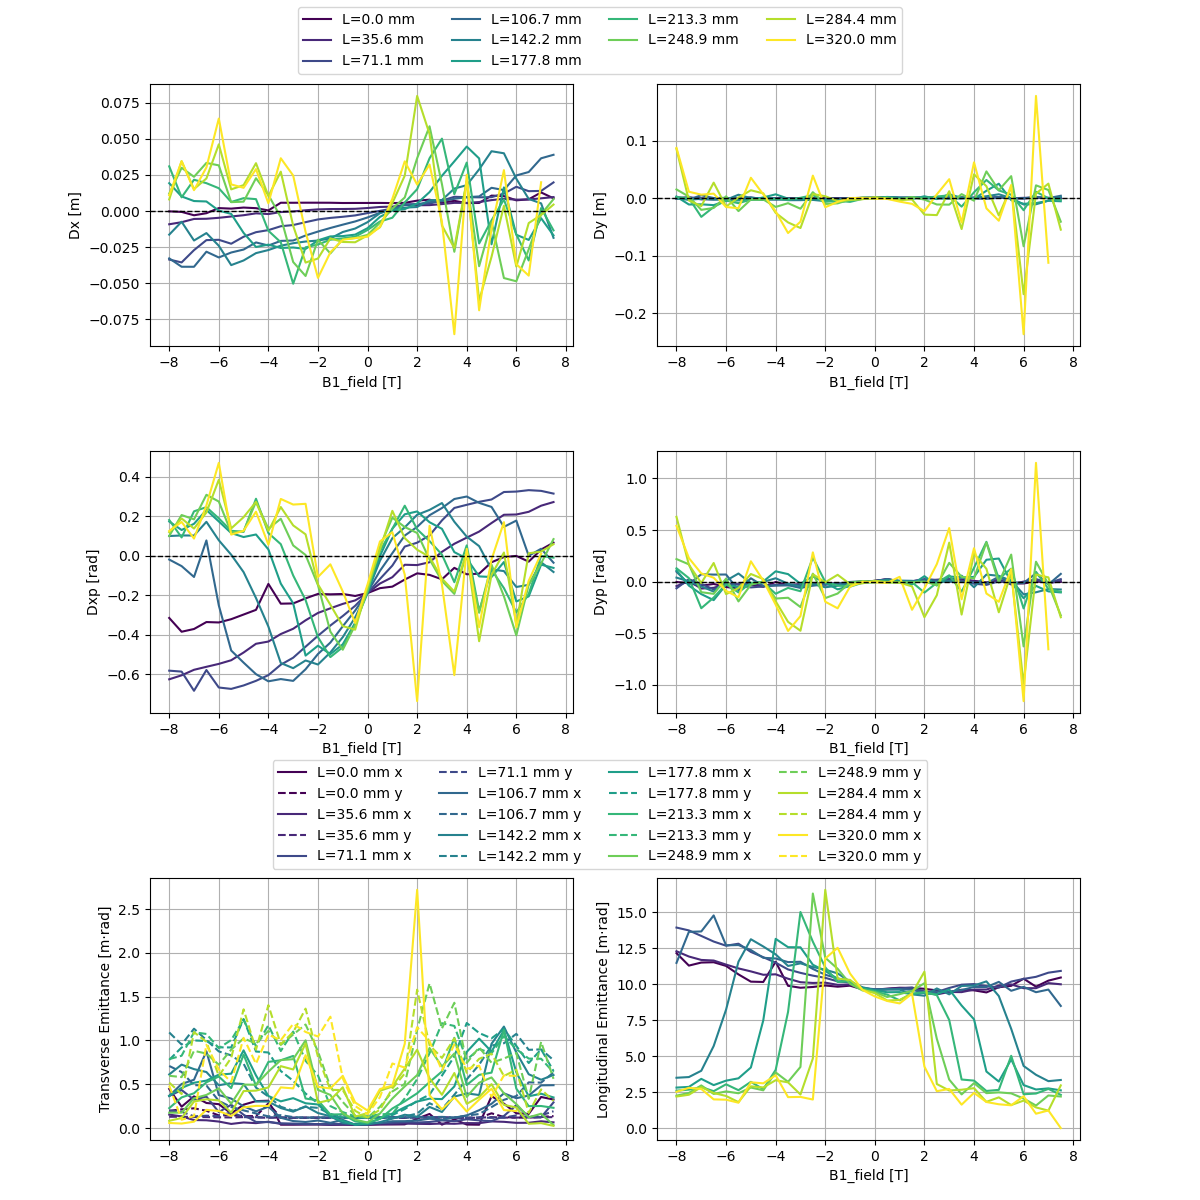

In [85]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for j, (data_key, label) in enumerate([
    ("Dx", "Dx [m]"),
    ("Dy", "Dy [m]"),
    ("Dxp", "Dxp [rad]"),
    ("Dyp", "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    ("emit_z", "Longitudinal Emittance [m·rad]")
]):
    ax = axs[j]

    for idx, res in enumerate(results):
        Dip1 = res["Dip1"]
        if label == "Transverse Emittance [m·rad]":
            ax.plot(Dip1, res["emit_x"], color=colors[idx], linestyle='-', label=f"L={res['B1_length']:.1f} mm x")
            ax.plot(Dip1, res["emit_y"], color=colors[idx], linestyle='--', label=f"L={res['B1_length']:.1f} mm y")
        else:
            ax.plot(Dip1, res[data_key], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")

    if "D" in label:
        ax.axhline(0, color='k', linestyle='--', linewidth=1)

    ax.set_xlabel("B1_field [T]")
    ax.set_ylabel(label)
    ax.grid(True)

# --- Create first legend for axs[0] (top center)
handles0, labels0 = axs[0].get_legend_handles_labels()
fig.legend(handles0, labels0, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=10)

# --- Create second legend for axs[5] (center gap between rows)
handles5, labels5 = axs[4].get_legend_handles_labels()
fig.legend(handles5, labels5, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.27), fontsize=10)

# --- Adjust general subplot layout
fig.subplots_adjust(hspace=0.4, top=0.93, bottom=0.1)

# --- Push last two plots down slightly
for ax in axs[4:]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.05, pos.width, pos.height])  # move down 5%


plt.show()


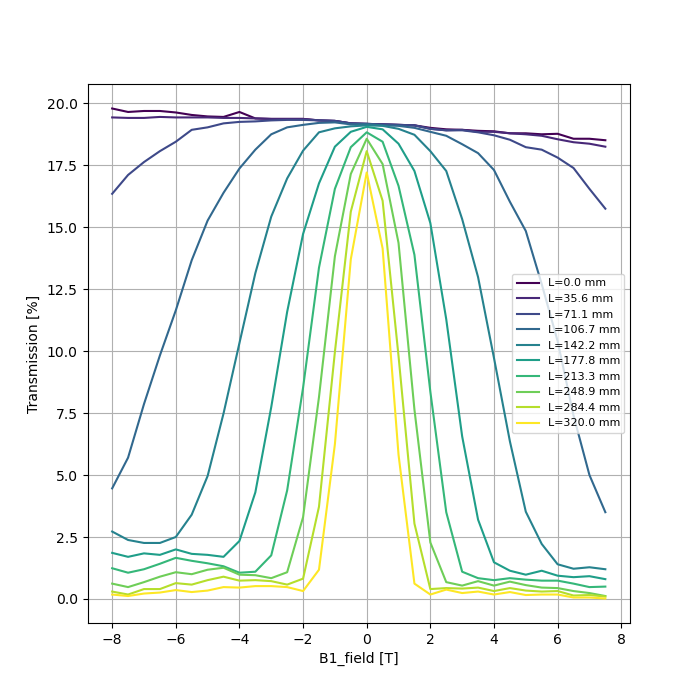

In [88]:
colors = viridis(np.linspace(0, 1, len(results)))

plt.figure(figsize=(7, 7))

for idx, res in enumerate(results):
    Dip1 = res["Dip1"]
    plt.plot(Dip1, res["transmission"], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")
    
plt.xlabel("B1_field [T]")
plt.legend(fontsize=8)
plt.ylabel("Transmission [%]")
plt.grid(True)

In [ ]:
colors = viridis(np.linspace(0, 1, len(results)))


fig, axs = plt.subplots(10, 2, figsize=(7, 7))

for idx, res in enumerate(results):
    for j, (data_key, label) in enumerate([("x", "x [mm]"), ("y", "y [mm]")]): 
        
        ax = axs[j]
        
        ax.scatter(res["y"], res["yp"], color=colors[idx], label=f"B={res["Dip1"]:.1f} T, L={res['B1_length']:.1f} mm")
        ax.scatter(res["x"], res["xp"], color=colors[idx], label=f"B={res["Dip1"]:.1f} T, L={res['B1_length']:.1f} mm")

## Scrap

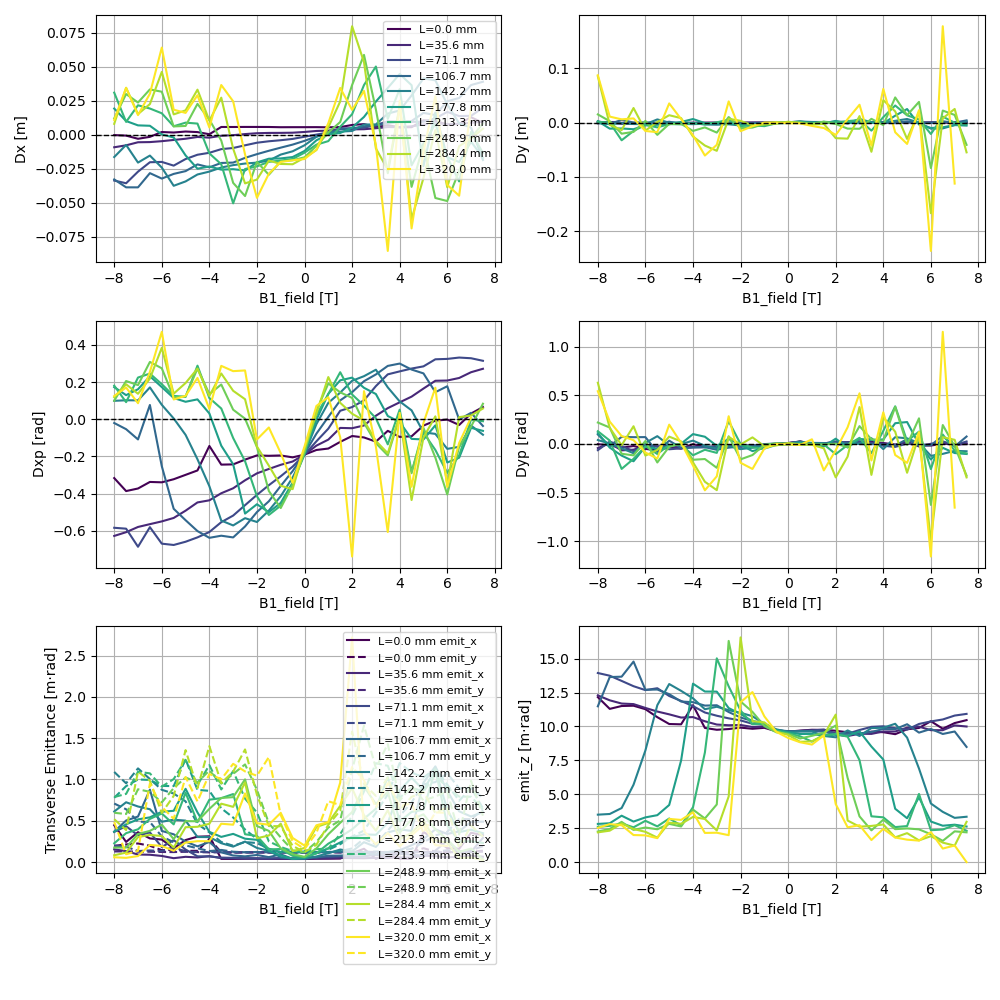

In [56]:
# Choose colors for each B1_length
colors = viridis(np.linspace(0, 1, len(results)))

fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.flatten()

for j, (data_key, label) in enumerate([
    ("Dx", "Dx [m]"),
    ("Dy", "Dy [m]"),
    ("Dxp", "Dxp [rad]"),
    ("Dyp", "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    ("emit_z", "emit_z [m·rad]")
]):
    ax = axs[j]

    for idx, res in enumerate(results):
        Dip1 = res["Dip1"]
        if label == "Transverse Emittance [m·rad]":
            ax.plot(Dip1, res["emit_x"], color=colors[idx], linestyle='-', label=f"L={res['B1_length']:.1f} mm emit_x")
            ax.plot(Dip1, res["emit_y"], color=colors[idx], linestyle='--', label=f"L={res['B1_length']:.1f} mm emit_y")
        else:
            ax.plot(Dip1, res[data_key], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")

    if "D" in label:
        ax.axhline(0, color='k', linestyle='--', linewidth=1)

    ax.set_xlabel("B1_field [T]")
    ax.set_ylabel(label)
    ax.grid(True)

# Add legends to appropriate plots
axs[0].legend(fontsize=8)
axs[4].legend(fontsize=8)

fig.tight_layout()
plt.show()


In [48]:
opt_bounds = np.arange(-8.0, 8.0, 0.05) # for B1, normal superconducting magnets
Dx = []
Dy = []
Dxp = []
Dyp = []
Dip1 = []
emit_z = []
emit_x = []
emit_y = []

for i, B_val in tqdm(enumerate(opt_bounds)):
        if os.path.exists("field_cell.dat"): 
                os.remove("field_cell.dat")
        var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length",
        "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
        "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME"]
        xvec = np.array([int(N_PARTICLES), B_val, 74.7401, geom["Length_Wedge"], 177.7, -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 
                        144.8055, 53.6328, 120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456, f"./runs/{VD_FILENAME}_{i}.txt"])
        calcparams = {name: val for name, val in zip(var_names, xvec)}
        
        add_missing_params(calcparams)
        write_input_from_template(TEMPLATE_FILE, f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{i}.g4bl", calcparams)
        
        result = subprocess.run(["g4bl", f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{i}.g4bl"], capture_output=True, text=True, check=True)
        
        G4BLOUTPUT =f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{VD_FILENAME}_{i}.txt"
        df = read_trackfile(G4BLOUTPUT)
        
        x_params, y_params, z_emit = calc_all_params(df)
        
        Dip1.append(B_val)
        Dx.append(x_params[4])
        Dy.append(y_params[4])
        Dxp.append(x_params[5])
        Dyp.append(y_params[5])
        emit_x.append(x_params[0])
        emit_y.append(y_params[0])
        emit_z.append(z_emit)


10it [00:20,  2.05s/it]


KeyboardInterrupt: 

In [ ]:
# Get 6 evenly spaced colors from the viridis colormap
show_col = viridis(np.linspace(0, 1, 7))

# Create figure and axes
fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.flatten()

# Define plot data and labels
plots = [
    (Dx, "Dx [m]"),
    (Dy, "Dy [m]"),
    (Dxp, "Dxp [rad]"),
    (Dyp, "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    (emit_z, "emit_z [m·rad]"),
]

for i, (data, label) in enumerate(plots):
    ax = axs[i]
    
    if label == "Transverse Emittance [m·rad]":
        # Special case: emit_x and emit_y in same plot
        ax.plot(Dip1, emit_x, color=show_col[i], label="emit_x", linewidth=2)
        ax.plot(Dip1, emit_y, color=show_col[(i + 1) % 6], label="emit_y", linewidth=2)
        ax.legend()
    else:
        ax.plot(Dip1, data, color=show_col[i], linewidth=2)
        # Add horizontal dashed line at y=0 for Dx, Dy, Dxp, Dyp
        if "D" in label:
            ax.axhline(0, color='k', linestyle='--', linewidth=1)

    ax.set_xlabel("Dip1 [arb. units]")
    ax.set_ylabel(label)
    ax.grid(True)

# fig.suptitle("Beam Parameters vs Dipole Field", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()